In [1]:
import pandas as pd

def flip_and_adjust_lanes_dynamically(tracks_df, aligned_df):
    """
    Dynamically flip lanes, adjust y-values, and handle road configurations:
    - Dynamically handle lanes based on drivingDirection (e.g., left-to-right or right-to-left).
    - Flip Lane IDs for one side and adjust y-values dynamically for both directions.
    """
    # Merge aligned information (ensure id alignment)
    tracks_df = tracks_df.merge(aligned_df[['id', 'drivingDirection']], on='id', how='left')

    # Determine the max lane ID
    max_lane = tracks_df['laneId'].max()

    # Check drivingDirection to separate left and right lanes
    if not tracks_df['drivingDirection'].isnull().any():
        left_to_right = tracks_df[tracks_df['drivingDirection'] == 1]['laneId'].unique()
        right_to_left = tracks_df[tracks_df['drivingDirection'] == 2]['laneId'].unique()
    else:
        # Default to split based on max_lane for uniform handling
        midpoint = max_lane // 2
        left_to_right = list(range(1, midpoint + 1))  # Lanes 1 to midpoint
        right_to_left = list(range(midpoint + 1, max_lane + 1))  # Lanes midpoint+1 to max_lane

    # Flip Lane IDs for left-to-right lanes dynamically (e.g., 1 ↔ max(left_to_right))
    lane_mapping = {lane: left_to_right[::-1][i] for i, lane in enumerate(left_to_right)}
    tracks_df.loc[tracks_df['laneId'].isin(left_to_right), 'laneId'] = \
        tracks_df['laneId'].map(lane_mapping)

    # Check if drivingDirection is available
    if 'drivingDirection' in tracks_df.columns:
        # Flip x values for direction reversal for left-to-right lanes
        max_x = tracks_df['x'].max()
        tracks_df.loc[tracks_df['laneId'].isin(left_to_right), 'x'] = max_x - tracks_df['x']

        # Negate xVelocity and xAcceleration for left-to-right lanes
        tracks_df.loc[tracks_df['laneId'].isin(left_to_right), 'xVelocity'] *= -1
        tracks_df.loc[tracks_df['laneId'].isin(left_to_right), 'xAcceleration'] *= -1

        # Update drivingDirection for left-to-right lanes
        tracks_df.loc[(tracks_df['drivingDirection'] == 2) & (tracks_df['laneId'].isin(left_to_right)), 'drivingDirection'] = 1

    # Adjust y-axis for left-to-right lanes using the global maximum
    if not tracks_df[tracks_df['laneId'].isin(left_to_right)].empty:
      max_y_left_to_right = tracks_df[tracks_df['laneId'].isin(left_to_right)]['y'].max()
      tracks_df.loc[tracks_df['laneId'].isin(left_to_right), 'y'] = \
        max_y_left_to_right - tracks_df.loc[tracks_df['laneId'].isin(left_to_right), 'y']


    # Adjust y-axis for right-to-left lanes using the global minimum
    if not tracks_df[tracks_df['laneId'].isin(right_to_left)].empty:
        min_y_right_to_left = tracks_df[tracks_df['laneId'].isin(right_to_left)]['y'].min()
        tracks_df.loc[tracks_df['laneId'].isin(right_to_left), 'y'] -= min_y_right_to_left  # Normalize y to start from 0


    return tracks_df

def process_files_with_dynamic_lanes(tracks_file, aligned_file, output_file):
    """
    Process tracks and aligned files, dynamically flip lanes, adjust y values, and save the output.
    """
    # Load main tracks file
    tracks_df = pd.read_csv(tracks_file)

    # Load aligned file with IDs and drivingDirection
    aligned_df = pd.read_csv(aligned_file)

    # Adjust lanes and y values dynamically
    adjusted_tracks_df = flip_and_adjust_lanes_dynamically(tracks_df, aligned_df)

    # Save the output
    adjusted_tracks_df.to_csv(output_file, index=False)
    print(f"Dynamic lane flipping and adjustment complete. File saved as '{output_file}'.")

# Main Execution
if __name__ == "__main__":
    # Input files
    tracks_file = "/content/01_tracks.csv"
    aligned_file = "/content/01_tracksMeta.csv"
    output_file = "dynamic_lanes_adjusted_tracks.csv"

    # Process and adjust
    process_files_with_dynamic_lanes(tracks_file, aligned_file, output_file)




Dynamic lane flipping and adjustment complete. File saved as 'dynamic_lanes_adjusted_tracks.csv'.


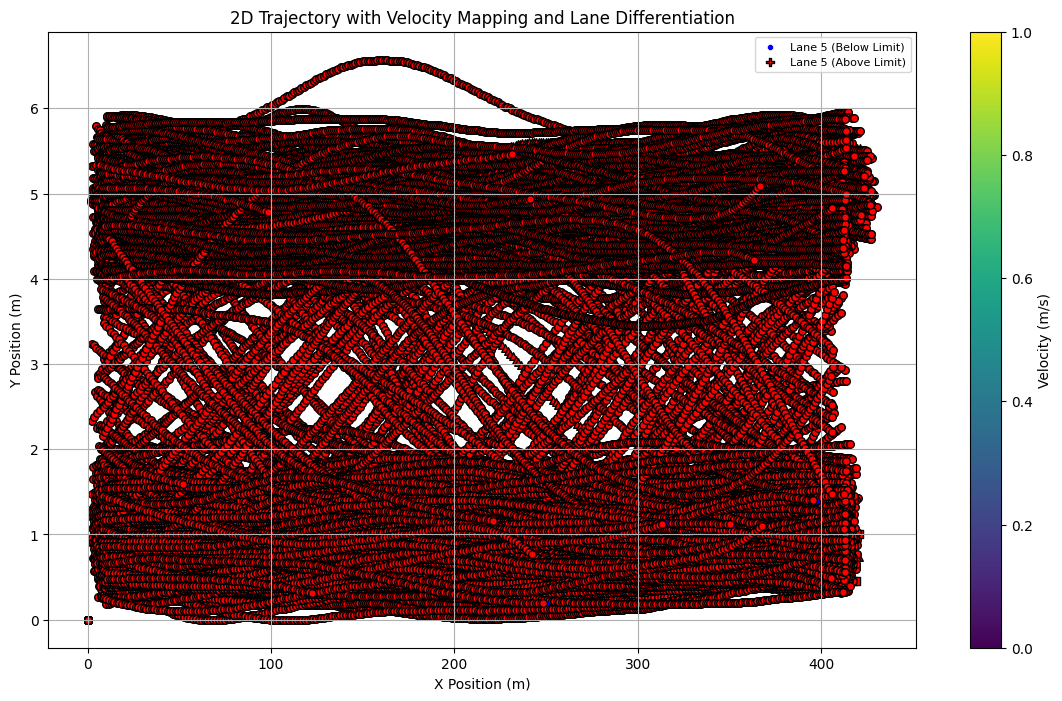

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data from 'traffic_scenario_data_combined.csv'
file_path = '/content/dynamic_lanes_adjusted_tracks.csv'
combined_df = pd.read_csv(file_path)

# Simulated Data (adapted for the dataset)
num_vehicles = combined_df['id'].nunique()  # Unique vehicles
num_frames = combined_df['frame'].max()  # Total frames
x_positions = combined_df.pivot(index='frame', columns='id', values='x').fillna(0).values.T  # X positions
y_positions = combined_df.pivot(index='frame', columns='id', values='y').fillna(0).values.T  # Y positions
lane_ids = combined_df.pivot(index='frame', columns='id', values='laneId').fillna(0).values.T  # Lane IDs
timestamps = np.linspace(0, 3, num_frames)  # Simulated time (seconds)

# Define lane speed limits
def get_speed_limit(lane_id):
    if lane_id in (1, 4):
        return 70  # km/h
    elif lane_id in (2, 5):
        return 90  # km/h
    elif lane_id in (3, 6):
        return 120  # km/h
    else:
        return 0

# Convert speed limit to m/s
velocity_limits = np.array([[get_speed_limit(lane) * 1000 / 3600 for lane in row] for row in lane_ids])

# Calculate velocities
velocities = np.sqrt(np.diff(x_positions, axis=1)**2 + np.diff(y_positions, axis=1)**2) / np.diff(timestamps)

# Add last frame with zeros to match the shape
velocities = np.hstack([velocities, np.zeros((num_vehicles, 1))])

# Define shapes for different lanes
lane_shapes = {
    1: 'o', 2: 's', 3: '^', 4: 'D', 5: 'P', 6: 'X'
}

# Create a 2D trajectory plot
plt.figure(figsize=(14, 8))
for i in range(num_vehicles):
    # Get the lane and marker for this vehicle
    lane_id = int(lane_ids[i, 0])  # Assume first frame lane as representative
    marker = lane_shapes.get(lane_id, 'o')  # Default to circle if lane not found

    # Highlight points exceeding speed limit in red
    above_limit = velocities[i] > velocity_limits[i]
    below_limit = ~above_limit

    # Plot points below speed limit
    plt.scatter(x_positions[i, below_limit], y_positions[i, below_limit],
                c='blue', s=10, label=f'Lane {lane_id} (Below Limit)' if i == 0 else "", marker=marker)

    # Plot points above speed limit with more intensity
    plt.scatter(x_positions[i, above_limit], y_positions[i, above_limit],
                c='red', edgecolor='black', s=30, label=f'Lane {lane_id} (Above Limit)' if i == 0 else "", marker=marker)

# Add a color bar for velocity
cbar = plt.colorbar()
cbar.set_label('Velocity (m/s)')

# Add labels and legend
plt.xlabel('X Position (m)')
plt.ylabel('Y Position (m)')
plt.title('2D Trajectory with Velocity Mapping and Lane Differentiation')
plt.legend(loc='upper right', fontsize=8)
plt.grid(True)

plt.show()